<a href="https://colab.research.google.com/github/ShivenGupta29/First-Repository/blob/main/assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statistics import mode

arr=np.array([10,20,30,40,50,60,70,80,90])
print("Array- ",arr)

print("Mean- ",np.mean(arr))
print("Median- ",np.median(arr))
print("Average- ",np.average(arr))
print("Mode- ",mode(arr))

Array-  [10 20 30 40 50 60 70 80 90]
Mean-  50.0
Median-  50.0
Average-  50.0
Mode-  10


Dataset:
   CGPA   IQ  Aptitude  Technical  Communication  Placed
0   6.5   90        55         50             55       0
1   7.2  100        65         60             65       0
2   8.1  115        75         80             75       1
3   5.8   80        45         40             50       0
4   7.8  105        70         75             70       1
5   9.0  125        85         90             85       1
6   6.2   85        50         45             48       0
7   8.5  120        80         85             82       1
8   7.0   95        60         55             60       0
9   5.5   75        40         35             45       0

Actual: [0 1]
Predicted: [0 1]

Model Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
[[1 0]
 [0 1]]

ROC-AUC: 1.0


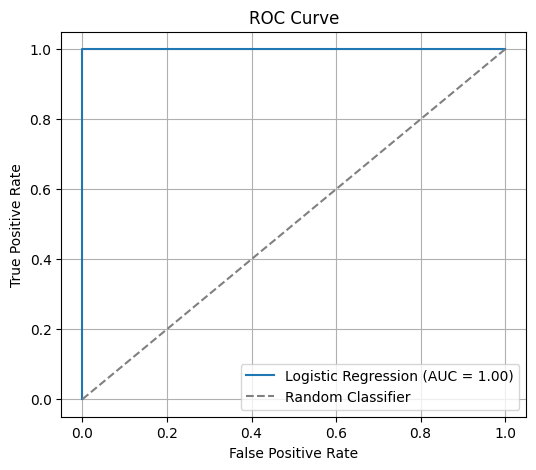


New Student Predictions:
Student 1: Placed (Probability = 0.90)
Student 2: Not Placed (Probability = 0.02)
Student 3: Placed (Probability = 0.64)
Student 4: Not Placed (Probability = 0.01)
Student 5: Placed (Probability = 0.96)


In [16]:
#Part-1
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

data = {
    "CGPA": [6.5, 7.2, 8.1, 5.8, 7.8, 9.0, 6.2, 8.5, 7.0, 5.5],
    "IQ": [90, 100, 115, 80, 105, 125, 85, 120, 95, 75],
    "Aptitude": [55, 65, 75, 45, 70, 85, 50, 80, 60, 40],
    "Technical": [50, 60, 80, 40, 75, 90, 45, 85, 55, 35],
    "Communication": [55, 65, 75, 50, 70, 85, 48, 82, 60, 45],
    "Placed": [0, 0, 1, 0, 1, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

X = df[[
    "CGPA",
    "IQ",
    "Aptitude",
    "Technical",
    "Communication"
]]

y = df["Placed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nActual:", y_test.to_numpy())
print("Predicted:", y_pred)

print("\nModel Evaluation:")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred, zero_division=0))

print("F1 Score:",
      f1_score(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

probability = model.predict_proba(X_test)[:, 1]

if len(set(y_test)) == 2:

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    print("\nROC-AUC:", auc)

    plt.figure(figsize=(6, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"Logistic Regression (AUC = {auc:.2f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")

    plt.legend()
    plt.grid()
    plt.show()

else:
    print("\nROC-AUC cannot be calculated because")
    print("the test set contains only one class.")

new_students = pd.DataFrame([
    [8.5, 120, 80, 85, 82],
    [6.0, 85, 45, 40, 50],
    [7.8, 110, 75, 70, 72],
    [5.5, 75, 40, 35, 45],
    [9.0, 125, 90, 92, 88]
], columns=[
    "CGPA",
    "IQ",
    "Aptitude",
    "Technical",
    "Communication"
])

result = model.predict(new_students)

probabilities = model.predict_proba(new_students)[:, 1]

print("\nNew Student Predictions:")

for i in range(len(new_students)):

    if result[i] == 1:
        status = "Placed"
    else:
        status = "Not Placed"

    print(
        f"Student {i + 1}: {status} "
        f"(Probability = {probabilities[i]:.2f})"
    )


House Data:
   Area  Price
0   500     20
1   700     27
2   900     35
3  1100     46
4  1300     60
5  1500     75
6  1700     93
7  1900    115
8  2100    140
9  2300    168

Degree: 2
MAE: 0.4655172413792723
MSE: 0.3062151706050899
RMSE: 0.5533671210011396
R2 Score: 0.9999040754418967


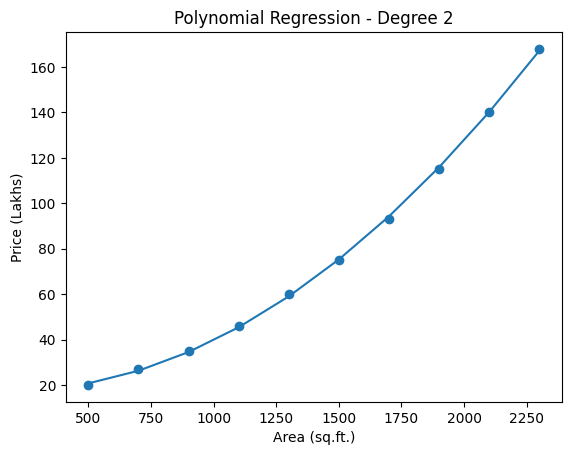


Degree: 3
MAE: 0.2991803281717278
MSE: 0.08958746144202069
RMSE: 0.299311646018027
R2 Score: 0.9999719359506799


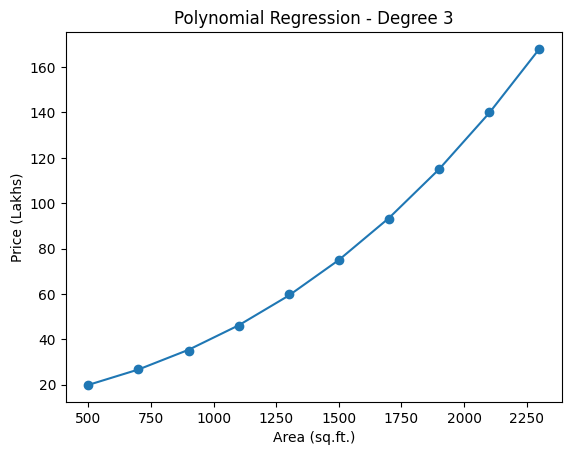


Degree: 4
MAE: 0.6860445750370978
MSE: 0.4707355650464959
RMSE: 0.6861017162538626
R2 Score: 0.9998525380013951


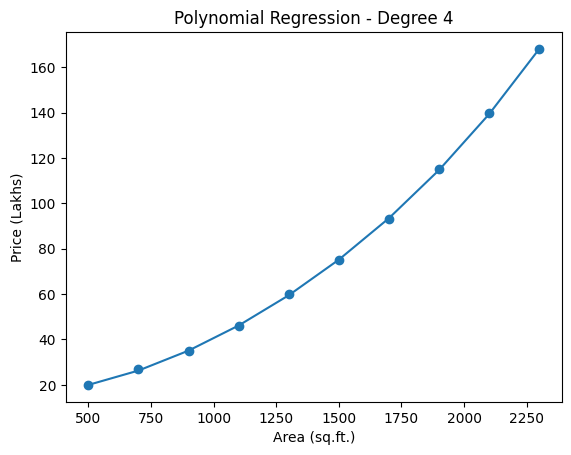


Predicted price for 2000 sq.ft.: 127.61761363636313 Lakhs


In [15]:
#Part-2

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    "Area": [500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2100, 2300],
    "Price": [20, 27, 35, 46, 60, 75, 93, 115, 140, 168]
}

df = pd.DataFrame(data)

print("House Data:")
print(df)

X = df[["Area"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for degree in [2, 3, 4]:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, prediction)

    print("\nDegree:", degree)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    plt.scatter(X, y)
    plt.plot(X, model.predict(X))
    plt.xlabel("Area (sq.ft.)")
    plt.ylabel("Price (Lakhs)")
    plt.title("Polynomial Regression - Degree " + str(degree))
    plt.show()

model = make_pipeline(
    PolynomialFeatures(2),
    LinearRegression()
)

model.fit(X, y)

price = model.predict([[2000]])

print("\nPredicted price for 2000 sq.ft.:", price[0], "Lakhs")